<a href="https://colab.research.google.com/github/madhumithasuresh-06/MachineLearningProjects/blob/main/MNIST_image_data_with_neural_networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MNIST Handwritten Digit Classification using Neural Networks

This is used to understand Neural Network

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import cv2
from PIL import Image
import tensorflow as tf
tf.random.set_seed(3)
from tensorflow import keras
from keras.datasets import mnist
from tensorflow.math import confusion_matrix
from google.colab.patches import cv2_imshow

In [35]:
#load MNIST datq from keras datasets
(x_train,y_train),(x_test,y_test)=mnist.load_data()
type(x_train)

numpy.ndarray

In [36]:
print(x_train.shape,y_train.shape,x_test.shape,y_test.shape)

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


Print the image

In [37]:
print(x_train[10])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  42 118 219 166 118 118   6
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 103 242 254 254 254 254 254  66
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0  18 232 254 254 254 254 254 238
   70   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 104 244 254 224 254 254 254
  141   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 207 254 210 25

In [38]:
print(x_train[10].shape)

(28, 28)


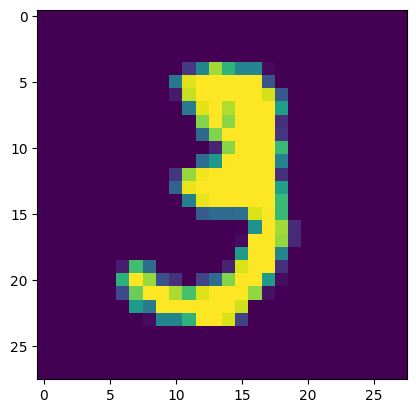

In [39]:
plt.imshow(x_train[10])
plt.show()

In [40]:
print(y_train[10])

3


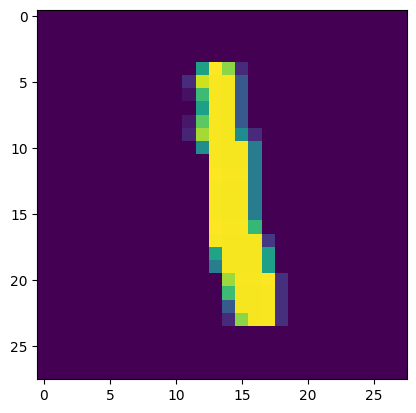

In [41]:
plt.imshow(x_train[6])
plt.show()

In [42]:
print(y_train[6])

1


Identify the target values

In [43]:
print(np.unique(y_train))

[0 1 2 3 4 5 6 7 8 9]


In [44]:
print(np.unique(y_test))

[0 1 2 3 4 5 6 7 8 9]


Scalling the values

In [45]:
x_train=x_train/255
x_test=x_test/255

Building the Neural Network

In [46]:
model=keras.Sequential([keras.layers.Flatten(input_shape=(28,28)),keras.layers.Dense(50,activation='relu'),keras.layers.Dense(50,activation='relu'),keras.layers.Dense(10,activation='softmax')])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [47]:
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [48]:
model.fit(x_train,y_train,epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9142 - loss: 0.2958
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9591 - loss: 0.1367
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9692 - loss: 0.1028
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9752 - loss: 0.0815
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9795 - loss: 0.0674
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9829 - loss: 0.0567
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9855 - loss: 0.0476
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9873 - loss: 0.0410
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9883 - loss: 0.0377
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9896 - loss: 0.0329


In [49]:
loss,accuracy=model.evaluate(x_test,y_test)
print(accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9693 - loss: 0.1268
0.9692999720573425


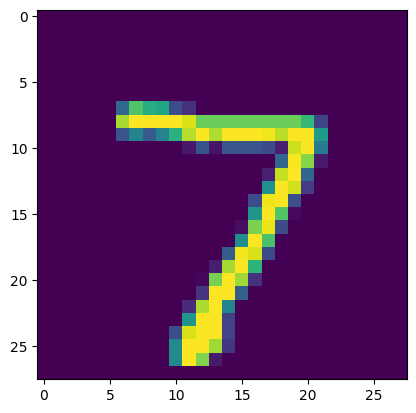

7


In [50]:
plt.imshow(x_test[0])
plt.show()
print(y_test[0])

In [51]:
y_pred=model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [52]:
print(y_pred[0])
print(y_pred.shape)

[1.58549465e-12 4.02686495e-10 2.19136177e-06 2.16210037e-06
 9.58902706e-15 4.74068642e-08 2.91078662e-23 9.99995530e-01
 2.04307508e-11 1.09782604e-07]
(10000, 10)


Argmax

In [53]:
label_first_image=np.argmax(y_pred[0])
print(label_first_image)

7


In [54]:
y_pred_labels=[np.argmax(i) for i in y_pred]
print(y_pred_labels)

[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4), np.int64(1), np.int64(4), np.int64(9), np.int64(5), np.int64(9), np.int64(0), np.int64(6), np.int64(9), np.int64(0), np.int64(1), np.int64(5), np.int64(9), np.int64(7), np.int64(3), np.int64(4), np.int64(9), np.int64(6), np.int64(6), np.int64(5), np.int64(4), np.int64(0), np.int64(7), np.int64(4), np.int64(0), np.int64(1), np.int64(3), np.int64(1), np.int64(3), np.int64(4), np.int64(7), np.int64(2), np.int64(7), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(7), np.int64(4), np.int64(2), np.int64(3), np.int64(5), np.int64(1), np.int64(2), np.int64(4), np.int64(4), np.int64(6), np.int64(3), np.int64(5), np.int64(5), np.int64(6), np.int64(0), np.int64(4), np.int64(1), np.int64(9), np.int64(5), np.int64(7), np.int64(8), np.int64(9), np.int64(3), np.int64(7), np.int64(4), np.int64(6), np.int64(4), np.int64(3), np.int64(0), np.int64(7), np.int64(0), np.int64(2), np.int64(9), np.int64(1), np.int64(7), np.int64(3)

Confusion Matrix

In [55]:
conf_matrix=confusion_matrix(y_test,y_pred_labels)
print(conf_matrix)

tf.Tensor(
[[ 956    0    1    1    2    1    5    4    3    7]
 [   0 1111    2    4    1    2    4    6    5    0]
 [   4    1  986   10    2    1    5   12   11    0]
 [   0    0    5  991    1    1    0    6    3    3]
 [   0    1    6    0  957    0    6    4    2    6]
 [   2    0    0   26    2  842   10    1    7    2]
 [   4    2    0    1    5    5  939    1    1    0]
 [   0    0    7    2    2    1    1 1006    2    7]
 [   3    0    3   13    3    3    2    3  942    2]
 [   0    2    0    8   23    2    0    7    4  963]], shape=(10, 10), dtype=int32)


In [56]:
plt.figure(figsize=(15,7))

<Figure size 1500x700 with 0 Axes>

<Figure size 1500x700 with 0 Axes>

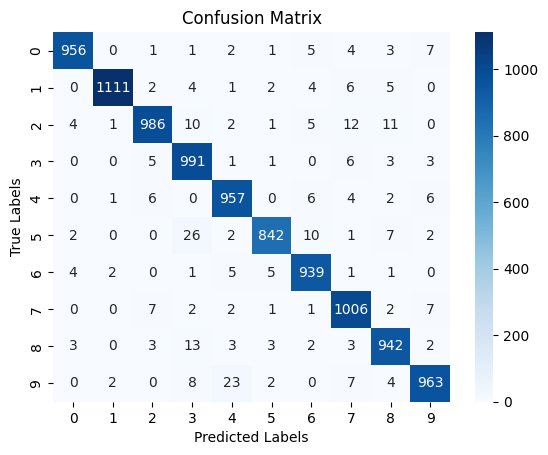

In [57]:
sns.heatmap(conf_matrix,annot=True,fmt="d",cmap="Blues")
plt.ylabel("True Labels")
plt.xlabel("Predicted Labels")
plt.title("Confusion Matrix")
plt.show()

BUILDING PREDICTIVE SYSTEM

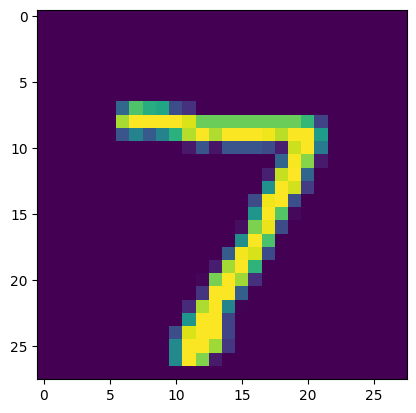

(413, 416, 3)
(413, 416)
(28, 28)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
[[0.0000000e+00 3.0721778e-23 3.5711801e-22 1.9962643e-13 0.0000000e+00
  3.2414658e-22 0.0000000e+00 1.0000000e+00 0.0000000e+00 3.6724203e-28]]
7


In [59]:
input_image_path="/content/download.png"
input_image=cv2.imread(input_image_path)
cv2_imshow(input_image)
print(input_image.shape)
grayscale=cv2.cvtColor(input_image,cv2.COLOR_BGR2GRAY)
print(grayscale.shape)
input_image_resize=cv2.resize(grayscale,(28,28))
print(input_image_resize.shape)
cv2_imshow(input_image_resize)
input_image_resize=input_image_resize/255
input_image_reshape=np.reshape(input_image_resize,[1,28,28])
input_prediction=model.predict(input_image_reshape)
print(input_prediction)
input_pred_label=np.argmax(input_prediction)
print(input_pred_label)